# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### Team Member 1 - Abhinibesh Mal
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

This project analyzes a 2014 survey on mental health attitudes and support in the tech workplace, using responses from over 1,200 employees across multiple countries. The goal was to explore how comfortable tech employees feel discussing mental health at work, how aware they are of the resources available to them, and what factors most strongly predict whether someone actually seeks treatment for a mental health condition — then translate these findings into practical recommendations for employers.

The raw dataset required several cleaning steps before analysis could begin. The Age column, being free-text in the original survey, contained a handful of clearly invalid entries — including negative numbers and one value in the billions — so it was filtered to a realistic working-age range of 18 to 100, removing 8 rows. The Gender column had dozens of inconsistent spellings and free-text variants (such as "M", "Cis Male", "femail", and others), which were standardized into three consistent categories: Male, Female, and Other. Missing values in self_employed and work_interfere were filled with sensible defaults rather than dropped, since they represented meaningful non-responses rather than data errors. Columns that added little analytical value — state (only applicable to US respondents), comments (87% empty free text), and the raw Timestamp — were removed, though a Year field was extracted from Timestamp first, revealing that the vast majority of responses (1,190 of 1,259) came from 2014, with only a small trailing tail into 2015 and 2016.

With the data cleaned, exploratory analysis covered demographic patterns, workplace policy awareness, and behavioral outcomes. The respondent base skews heavily toward men in their late 20s to mid-30s, based primarily in the United States, which is an important limitation to keep in mind when generalizing the findings. Roughly half of respondents reported having sought treatment for a mental health condition, and this outcome was most strongly associated with two factors: having a family history of mental illness, and working for an employer that actively provides and discusses mental health benefits. A consistent theme across several charts was uncertainty rather than absence — many respondents answered "don't know" when asked about care options, anonymity protections, and leave policies, suggesting that in many cases, the real barrier isn't a lack of support, but a lack of clear communication about support that may already exist.

A correlation heatmap, built after label-encoding the categorical variables, confirmed that family history and treatment-seeking were more strongly related than most other variable pairs in the dataset, reinforcing the pattern seen in the categorical breakdowns. A pair plot of the dataset's two genuinely numeric fields, Age and Year, showed no meaningful separation by treatment status, indicating that demographic and time-based factors alone are weak predictors compared to workplace policy and personal history factors.

Based on these findings, the recommended path forward for an employer is threefold: improve communication of existing policies rather than assuming new ones are needed, continue and expand visible wellness and benefits programs given their clear association with treatment-seeking, and consider more targeted outreach for employees with a known family history of mental illness. Given the dataset's skew toward male, US-based, 2014 respondents, these conclusions are best treated as directional insights to validate against a company's own internal survey data, rather than universal truths about the tech workforce as a whole.

To make these findings accessible beyond a technical audience, the analysis was also built into an interactive Streamlit web app, allowing anyone to explore the survey data and view the key charts without needing to read code.

# **GitHub Link -**

[Github Link](https://github.com/abhinibeshmal)

# **Problem Statement**


Mental health remains a widely under-discussed issue in workplaces, and this is especially true in the tech industry, where high-pressure environments, long hours, and a culture that historically prioritizes productivity over wellbeing can make it difficult for employees to seek support. Using a 2014 survey of over 1,200 tech industry employees, this project investigates the current state of workplace mental health support — how comfortable employees feel discussing mental health with employers and coworkers, whether they are aware of the resources available to them, and what factors most strongly predict whether someone seeks treatment. The core problem this project addresses is that employers often don't have a clear, data-backed picture of whether their existing mental health policies are actually reaching and helping employees, or whether awareness gaps are silently undermining otherwise well-intentioned programs.

#### **Define Your Business Objective?**

The business objective is to help an employer understand which factors most influence whether an employee seeks mental health treatment, and to identify concrete, low-cost ways to improve support and communication around existing mental health resources. Rather than assuming more policies are always the answer, this project aims to distinguish between two different problems — genuine gaps in support, and simple lack of awareness about support that already exists — so that HR and wellness teams can act on the right one.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [266]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)

### Dataset Loading

In [224]:
# Load Dataset

df = pd.read_csv("survey.csv")

### Dataset First View

In [225]:
# Dataset First Look

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [226]:
# Dataset Rows & Columns count

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1259
Number of columns: 27


### Dataset Information

In [227]:
# Dataset Info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [228]:
# Dataset Duplicate Value Count

print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [229]:
# Missing Values/Null Values Count

df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

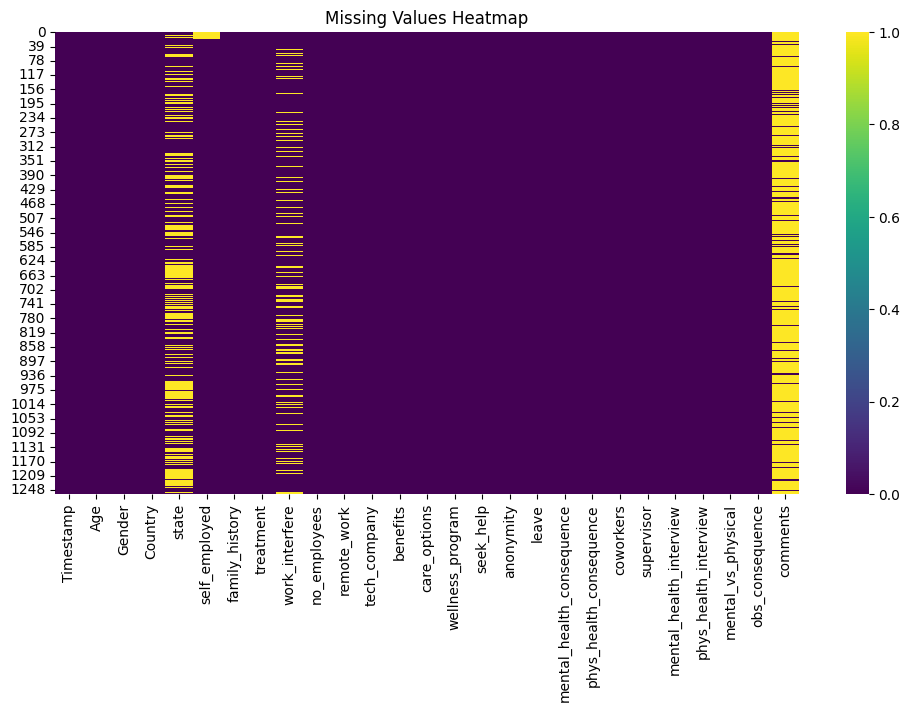

In [230]:
# Visualizing the missing values

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains 1,259 responses to a 2014 survey on mental health attitudes in the tech workplace, across 27 columns. Most columns are categorical (Yes/No or multiple-choice responses about workplace policies and attitudes). Two columns have significant missing data: 'comments' (1,095 missing, mostly optional free-text) and 'state' (515 missing, since it only applies to US-based respondents). 'work_interfere' has 264 missing values, likely from respondents who don't have a mental health condition at all. 'self_employed' has 18 missing values. There are no duplicate rows in the dataset.

## ***2. Understanding Your Variables***

In [231]:
# Dataset Columns

df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='str')

In [232]:
# Dataset Describe

df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


### Variables Description

The dataset mixes demographic fields (Age, Gender, Country, state) with workplace policy questions (benefits, care_options, wellness_program, seek_help, anonymity, leave) and personal attitude/experience questions (family_history, treatment, work_interfere, mental_health_consequence, coworkers, supervisor, mental_health_interview, obs_consequence). Age is the only true numeric column; everything else is categorical or free text. The Age column will need cleaning, since a survey allows free-text entry and can contain unrealistic values (e.g. negative numbers or ages in the thousands).

### Check Unique Values for each variable.

In [233]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} number of unique values")

Timestamp: 1246 number of unique values
Age: 53 number of unique values
Gender: 49 number of unique values
Country: 48 number of unique values
state: 45 number of unique values
self_employed: 2 number of unique values
family_history: 2 number of unique values
treatment: 2 number of unique values
work_interfere: 4 number of unique values
no_employees: 6 number of unique values
remote_work: 2 number of unique values
tech_company: 2 number of unique values
benefits: 3 number of unique values
care_options: 3 number of unique values
wellness_program: 3 number of unique values
seek_help: 3 number of unique values
anonymity: 3 number of unique values
leave: 5 number of unique values
mental_health_consequence: 3 number of unique values
phys_health_consequence: 3 number of unique values
coworkers: 3 number of unique values
supervisor: 3 number of unique values
mental_health_interview: 3 number of unique values
phys_health_interview: 3 number of unique values
mental_vs_physical: 3 number of uniq

## 3. ***Data Wrangling***

### Data Wrangling Code

In [234]:
df_copy = df.copy() # copying the main dataframe so that no problem occures to the original one

# 1. Converting Timestamp to datetime and extracting Year

df_copy['Timestamp'] = pd.to_datetime(df_copy['Timestamp'])
df_copy['Year'] = df_copy['Timestamp'].dt.year

# 2. Clean Age column - remove unrealistic values (survey allows free text entry)

# print(df_copy[(df_copy["Age"] < 18) | (df_copy["Age"] > 100)]["Age"].to_list())
df_copy = df_copy[(df_copy['Age'] >= 18) & (df_copy['Age'] <= 100)]

# 3. Standardizing Gender into consistent categories

# df_copy["Gender"].unique()
def clean_gender(g):
    g = str(g).strip().lower()
    male_terms = ['male', 'm', 'man', 'cis male', 'male-ish', 'maile', 'mal',
                  'msle', 'make', 'cis man', 'malr', 'mail', 'guy (-ish) ^_^']
    female_terms = ['female', 'f', 'woman', 'cis female', 'femake', 'femail',
                     'cis-female/femme', 'female (cis)']
    if g in male_terms:
        return 'Male'
    elif g in female_terms:
        return 'Female'
    else:
        return 'Other'

df_copy['Gender'] = df_copy['Gender'].apply(clean_gender)

# 4. Handling missing values

# print(df_copy['self_employed'].value_counts(dropna=False))
df_copy['self_employed'] = df_copy['self_employed'].fillna('No')

# print(df_copy['work_interfere'].value_counts(dropna=False))
df_copy['work_interfere'] = df_copy['work_interfere'].fillna('Not applicable')

# 5. Droping columns not useful for structured analysis

df_copy = df_copy.drop(columns=['state', 'comments', 'Timestamp'])

df_copy = df_copy.reset_index(drop=True)

print("Shape after wrangling:", df_copy.shape)
df_copy.isnull().sum()

Shape after wrangling: (1251, 25)


Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
Year                         0
dtype: int64

### What all manipulations have you done and insights you found?

Several cleaning steps were applied to make the dataset analysis-ready. The Timestamp column was converted to datetime, and a Year column was extracted from it — this showed that responses are heavily concentrated in 2014 (1,190 of 1,259), with a small trailing tail into 2015 and just one response in 2016, so year-over-year comparisons aren't statistically reliable. The Age column contained unrealistic entries (since it was free-text in the original survey, including values like -1726 and 99999999999), so it was filtered to a plausible working-age range of 18–100, removing 8 clearly invalid rows. Gender had dozens of inconsistent free-text variants (e.g. "M", "Male-ish", "Cis Male", "femail") which were standardized into three consistent categories: Male, Female, and Other. Missing values in self_employed were filled with "No" (the majority response), and missing values in work_interfere were filled with "Not applicable," since these are largely respondents without a mental health condition to report on. The state column was dropped since it only applies to US-based respondents and would introduce bias if used broadly; comments was dropped since it was mostly empty free text (87% missing); and the raw Timestamp column was dropped after the Year field was extracted from it, since the exact date carries no further value. After these steps, the dataset is clean, consistent, and ready for visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1: Age Distribution

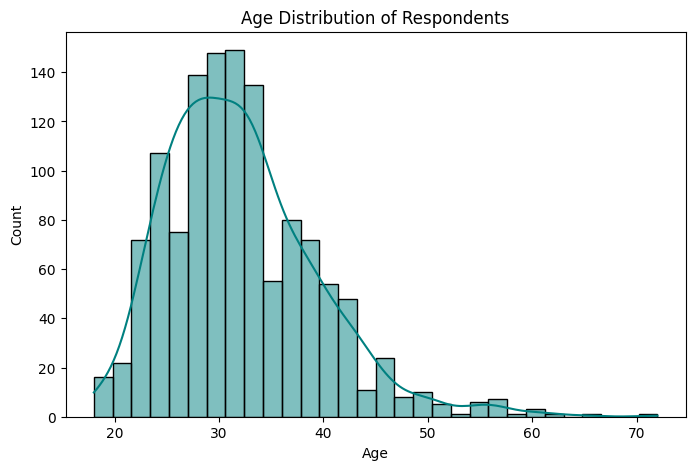

In [235]:
# Chart - 1:  Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df_copy["Age"], bins=30, kde=True, color='teal')
plt.title("Age Distribution of Respondents")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the standard way to show the spread and shape of a single numeric variable.

##### 2. What is/are the insight(s) found from the chart?

Most respondents fall between their mid-20s and mid-30s, showing the survey skews toward early-to-mid career tech professionals.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — it tells an employer that most respondents are early-career, so mental health programs should be tailored to that age group's needs rather than assuming a broad multi-generational workforce.

#### Chart - 2: Gender Distribution

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\1777283423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='Gender', palette='Set2', order=df_copy['Gender'].value_counts().index)


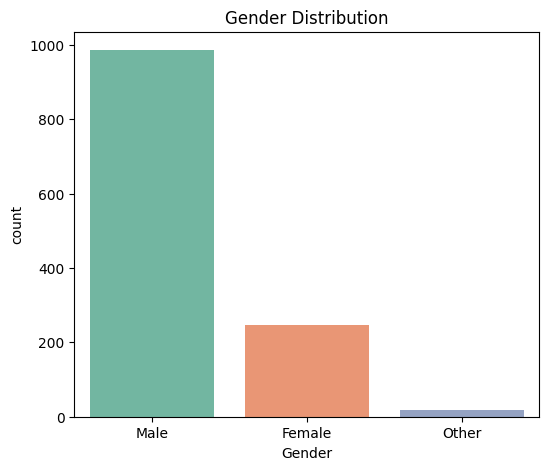

In [236]:
# Chart - 2:  Gender Distribution

plt.figure(figsize=(6,5))
sns.countplot(data=df_copy, x='Gender', palette='Set2', order=df_copy['Gender'].value_counts().index)
plt.title('Gender Distribution')
plt.show()

##### 1. Why did you pick the specific chart?

A countplot is ideal for comparing frequency across a small number of categories.

##### 2. What is/are the insight(s) found from the chart?

The dataset is heavily male-dominated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Slightly negative if unaddressed — findings drawn from this dataset may not generalize well to female or non-binary employees, since their sample is much smaller.

#### Chart - 3: Treatment Distribution (target variable)

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\3560814126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='treatment', palette='Set1')


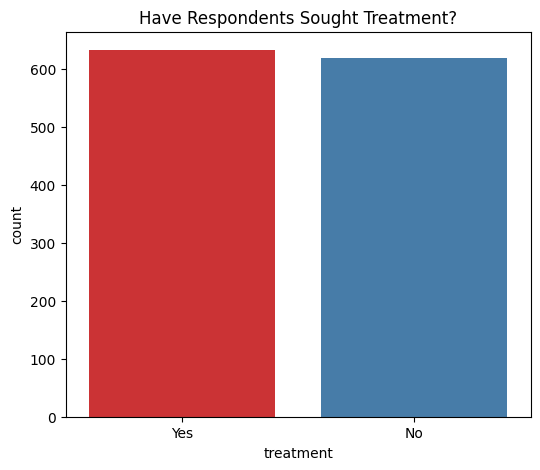

In [237]:
# Chart - 3: Treatment Distribution 

plt.figure(figsize=(6,5))
sns.countplot(data=df_copy, x='treatment', palette='Set1')
plt.title('Have Respondents Sought Treatment?')
plt.show()

##### 1. Why did you pick the specific chart?

This is the core outcome variable of the whole survey, so a simple count comparison is the clearest starting point.

##### 2. What is/are the insight(s) found from the chart?

The split between those who have and haven't sought treatment is close to even, suggesting treatment-seeking isn't rare, but it's also not universal.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — a near-even split validates that this is a real, well-distributed issue worth an employer's continued investment in support programs.

#### Chart - 4: Family History vs Treatment

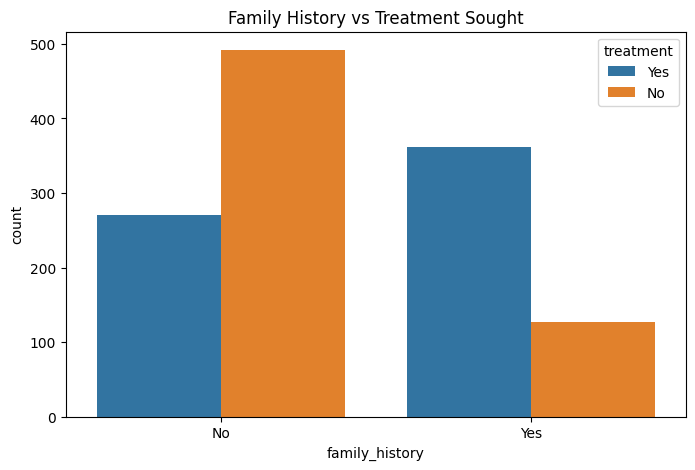

In [238]:
# Chart - 4: Family History vs Treatment

plt.figure(figsize=(8,5))
sns.countplot(data=df_copy, x='family_history', hue='treatment')
plt.title("Family History vs Treatment Sought")
plt.show()

##### 1. Why did you pick the specific chart?

A grouped countplot shows how one categorical variable relates to another — ideal for testing whether family history predicts treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?

Respondents with a family history of mental illness are noticeably more likely to have sought treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this confirms family history is a strong predictor, which can help HR/wellness teams identify at-risk groups for proactive outreach.

#### Chart - 5: Work Interference Distribution

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\291552343.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='work_interfere', order=df_copy["work_interfere"].value_counts().index, palette="Set2")


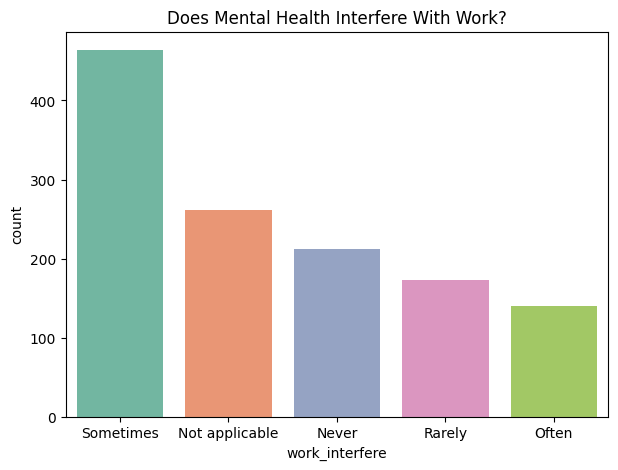

In [239]:
# Chart - 5: Work Interference Distribution

plt.figure(figsize=(7,5))
sns.countplot(data=df_copy, x='work_interfere', order=df_copy["work_interfere"].value_counts().index, palette="Set2")
plt.title("Does Mental Health Interfere With Work?")
plt.show()

##### 1. Why did you pick the specific chart?

A countplot ranks the frequency of each interference level clearly.

##### 2. What is/are the insight(s) found from the chart?

"Sometimes" is the most common response, showing that for many, mental health issues aren't constant but do periodically affect productivity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — reinforces the case for flexible, on-demand support (like an EAP) rather than one-size-fits-all policies.

#### Chart - 6: Company Size Distribution

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\1251447340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='no_employees', order=order, palette='viridis')


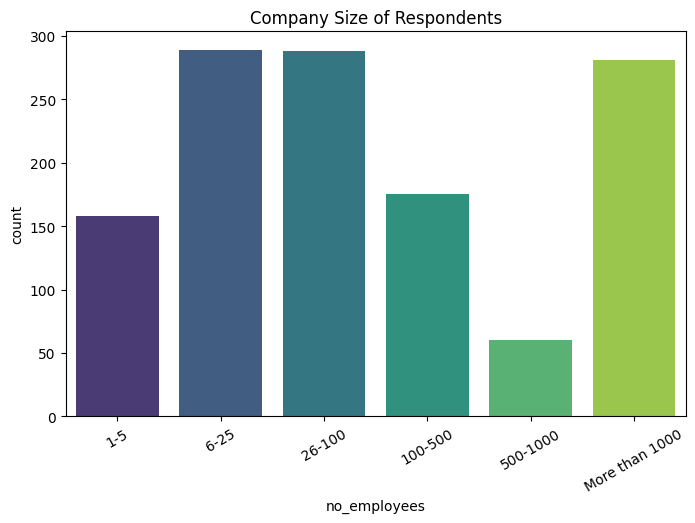

In [240]:
# Chart - 6 visualization code

plt.figure(figsize=(8,5))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sns.countplot(data=df_copy, x='no_employees', order=order, palette='viridis')
plt.title('Company Size of Respondents')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

A countplot with a logical manual ordering (small to large) is clearer than default alphabetical ordering.

##### 2. What is/are the insight(s) found from the chart?

Respondents span all company sizes fairly broadly, with large enterprises (1000+) and small startups (6-25) both well represented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this means findings aren't biased toward only large or only small companies, so recommendations can apply broadly.

#### Chart - 7: Remote Work vs Treatment

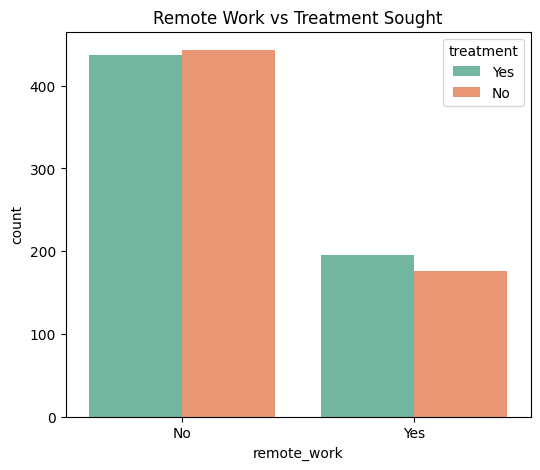

In [241]:
# Chart - 7 visualization code

plt.figure(figsize=(6,5))
sns.countplot(data=df_copy, x='remote_work', hue='treatment', palette='Set2')
plt.title('Remote Work vs Treatment Sought')
plt.show()

##### 1. Why did you pick the specific chart?

Grouped countplot to compare treatment-seeking behavior across a binary condition (remote vs not).

##### 2. What is/are the insight(s) found from the chart?

Treatment-seeking rates look similar between remote and in-office workers, suggesting remote work status alone isn't a strong driver.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral — tells an employer that remote work policy alone isn't likely to be a major mental health risk factor either way.

#### Chart - 8: Benefits vs Treatment

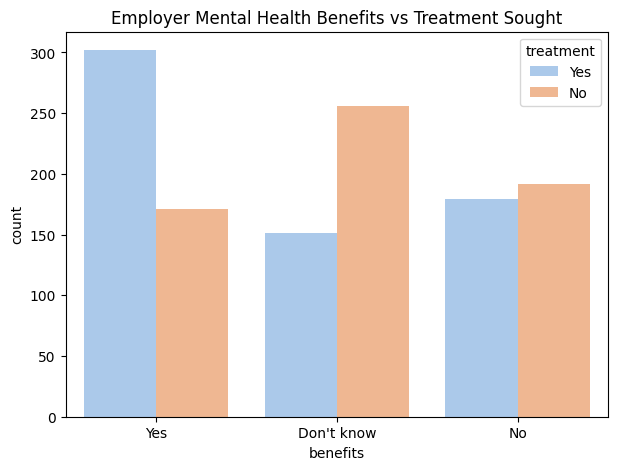

In [242]:
# Chart - 8 visualization code

plt.figure(figsize=(7,5))
sns.countplot(data=df_copy, x='benefits', hue='treatment', palette='pastel')
plt.title('Employer Mental Health Benefits vs Treatment Sought')
plt.show()

##### 1. Why did you pick the specific chart?

Grouped countplot tests whether having benefits available correlates with actually seeking treatment.

##### 2. What is/are the insight(s) found from the chart?

Respondents whose employer offers benefits show a higher rate of seeking treatment compared to those who say "No" or "Don't know."

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — strong evidence that offering (and clearly communicating) mental health benefits leads to more employees actually getting help.

#### Chart - 9: Care Options Awareness

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\2511763923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='care_options', palette='cool')


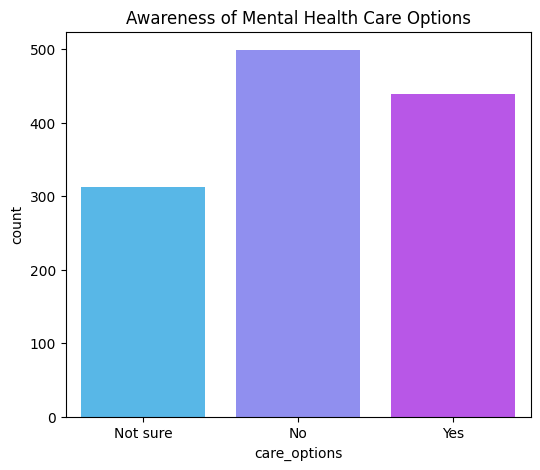

In [251]:
# Chart - 9 visualization code

plt.figure(figsize=(6,5))
sns.countplot(data=df_copy, x='care_options', palette='cool')
plt.title('Awareness of Mental Health Care Options')
plt.show()

##### 1. Why did you pick the specific chart?

Simple countplot to gauge overall awareness levels.

##### 2. What is/are the insight(s) found from the chart?

A large portion of respondents are unsure ("Not sure") whether care options exist, pointing to a communication gap rather than a lack of actual benefits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive if acted on — employers may already offer care options but aren't communicating them effectively; fixing this is a low-cost, high-impact improvement.

#### Chart - 10: Wellness Program vs Treatment

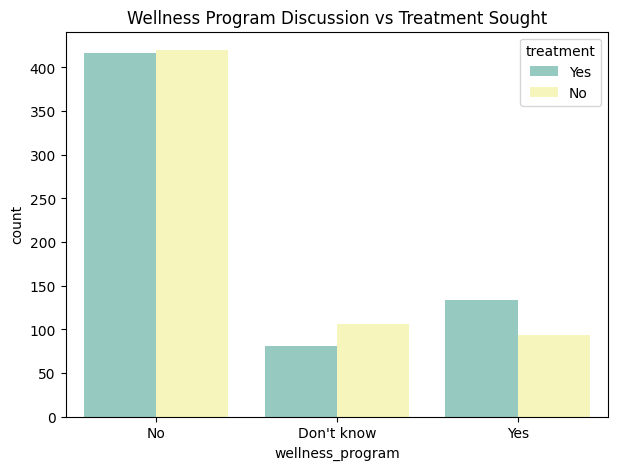

In [252]:
# Chart - 10 visualization code

plt.figure(figsize=(7,5))
sns.countplot(data=df_copy, x='wellness_program', hue='treatment', palette='Set3')
plt.title('Wellness Program Discussion vs Treatment Sought')
plt.show()

##### 1. Why did you pick the specific chart?

Grouped countplot, same logic as the benefits chart, testing a related but distinct policy.

##### 2. What is/are the insight(s) found from the chart?

Similar to benefits, employees whose employer discusses wellness programs are more likely to have sought treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — reinforces that visible, actively-discussed programs (not just passive policies) drive real behavior change.

#### Chart - 11: Anonymity vs Treatment

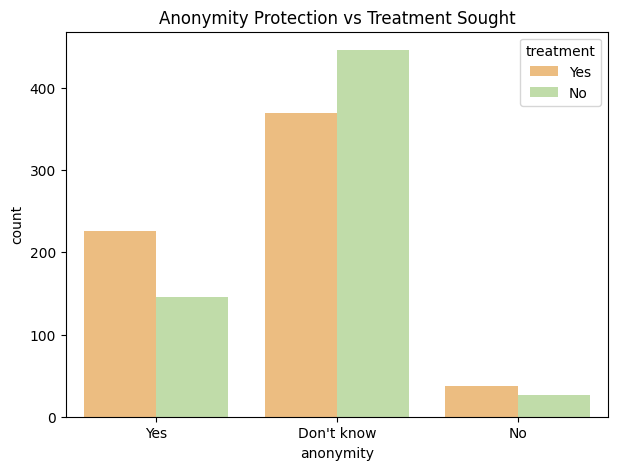

In [253]:
# Chart - 11 visualization code

plt.figure(figsize=(7,5))
sns.countplot(data=df_copy, x='anonymity', hue='treatment', palette='Spectral')
plt.title('Anonymity Protection vs Treatment Sought')
plt.show()

##### 1. Why did you pick the specific chart?

Grouped countplot to test whether perceived confidentiality affects treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?

Most respondents answered "Don't know" for anonymity, and this group shows lower treatment-seeking than those who confidently said "Yes."

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — suggests employers should clearly communicate anonymity protections, since uncertainty itself seems to be a barrier.

#### Chart - 12: Ease of Taking Leave

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\1318425827.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='leave', palette='rocket', order=order)


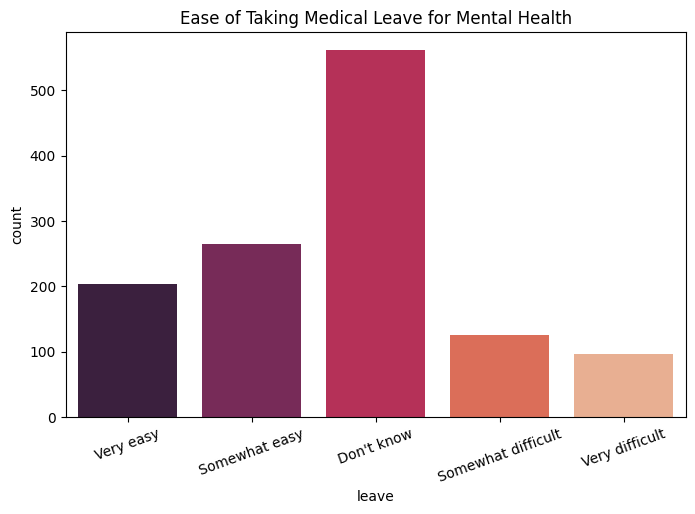

In [256]:
# Chart - 12 visualization code

plt.figure(figsize=(8,5))
order = ['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult']
sns.countplot(data=df_copy, x='leave', palette='rocket', order=order)
plt.xticks(rotation=20)
plt.title('Ease of Taking Medical Leave for Mental Health')
plt.show()

##### 1. Why did you pick the specific chart?

Countplot with a manually meaningful order (easy to difficult) instead of default sorting.

##### 2. What is/are the insight(s) found from the chart?

A large "Don't know" segment stands out again, showing many employees are simply unaware of their leave policy for mental health.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — another low-cost fix opportunity: clearer internal communication of existing leave policies.

#### Chart - 13: Top 10 Countries by Respondent Count

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\426154200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


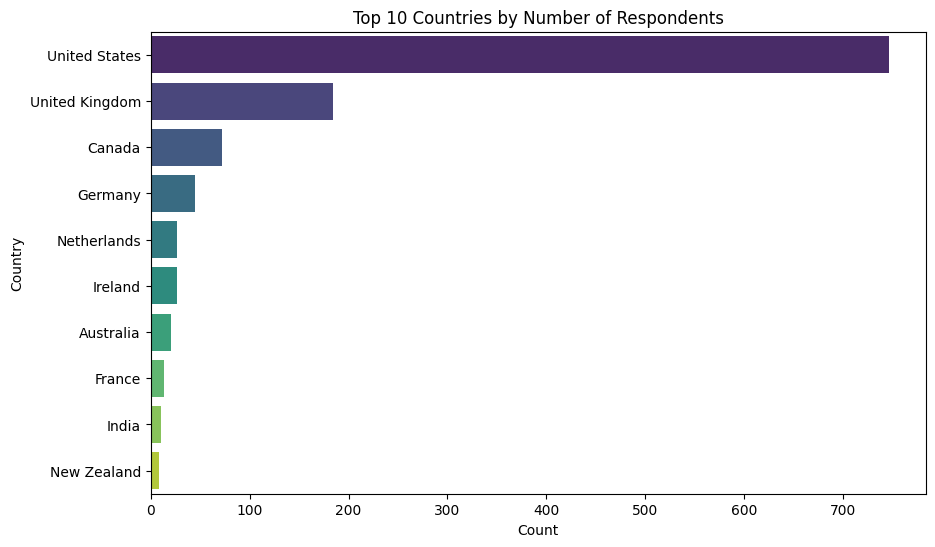

In [265]:
# Chart - 13 visualization code
plt.figure(figsize=(10,6))
top_countries = df_copy["Country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title("Top 10 Countries by Number of Respondents")
plt.xlabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart handles long category labels (country names) better than a vertical one.

##### 2. What is/are the insight(s) found from the chart?

The United States dominates the response count by a large margin, followed by the UK and Canada.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative if ignored — findings are heavily US-centric, so any recommendations should be flagged as most reliable for US-based teams rather than assumed to be globally representative.

#### Chart - 14 - Correlation Heatmap

C:\Users\RONY\AppData\Local\Temp\ipykernel_15460\2906990463.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


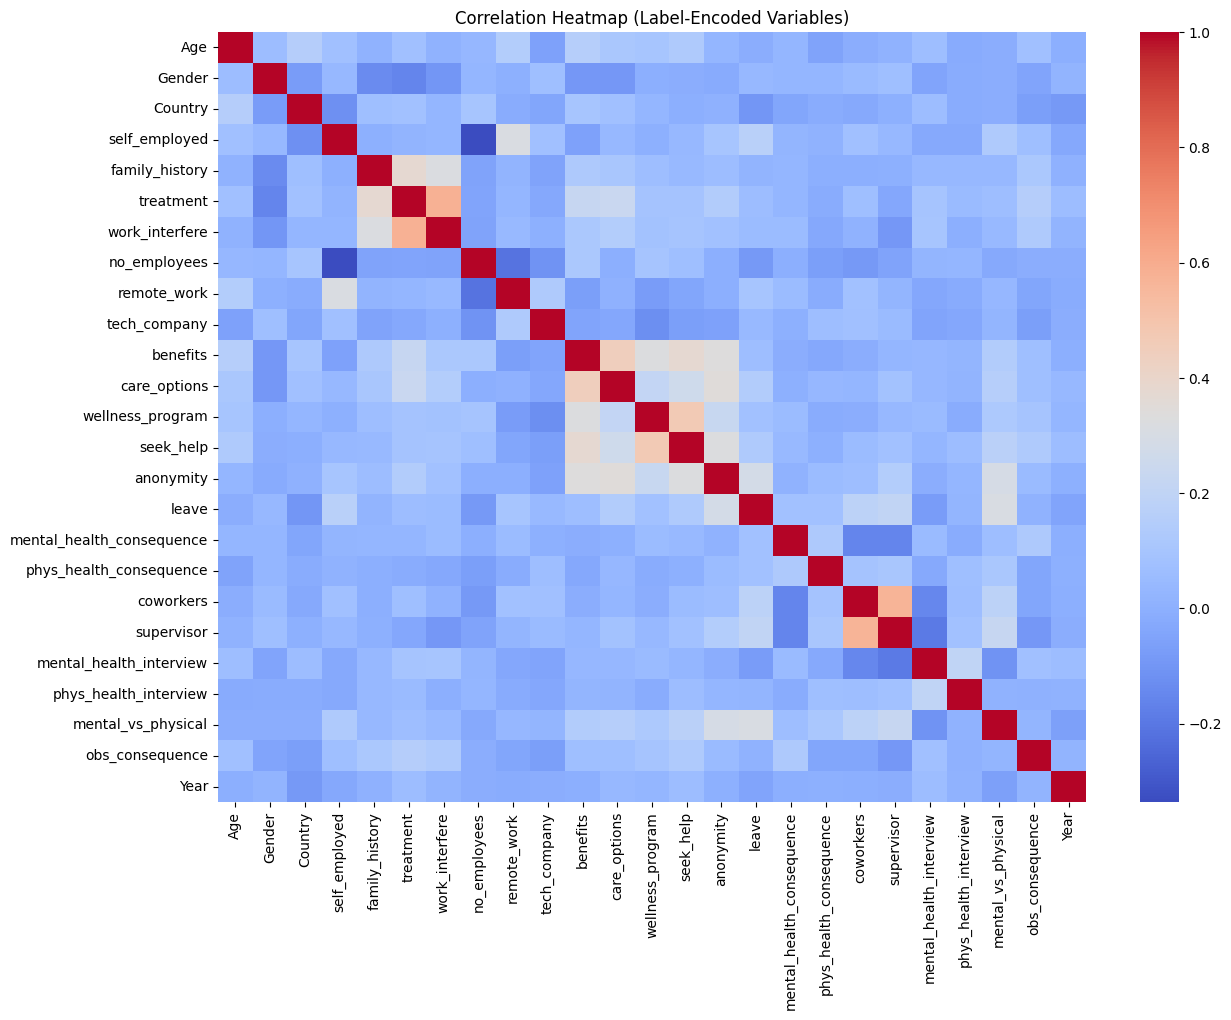

In [270]:
# Correlation Heatmap visualization code

df_encoded = df_copy.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (Label-Encoded Variables)')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the standard way to see many pairwise correlations at once; label encoding is needed since almost every column here is categorical, not numeric.

##### 2. What is/are the insight(s) found from the chart?

family_history and treatment show a noticeably stronger positive correlation than most other variable pairs, confirming the pattern seen in Chart 4.

#### Chart - 15 - Pair Plot

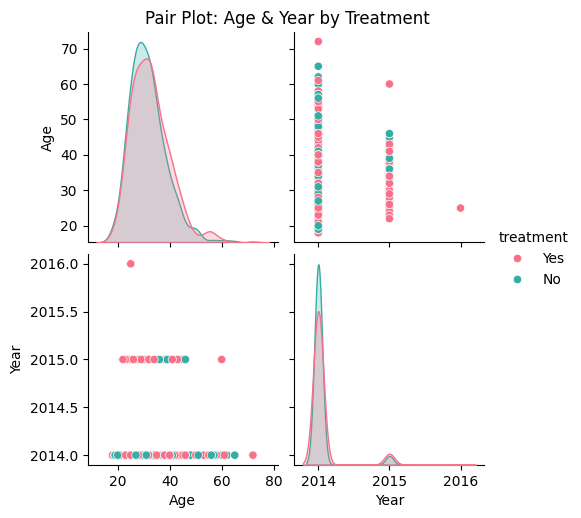

In [271]:
# Pair Plot visualization code

sns.pairplot(df_copy, vars=['Age', 'Year'], hue='treatment', palette='husl')
plt.suptitle('Pair Plot: Age & Year by Treatment', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows relationships between numeric variables; since this dataset has only Age and Year as true numeric fields, those are the only valid pair-plot candidates, split by the target variable for extra context.

##### 2. What is/are the insight(s) found from the chart?

No strong visual separation between treatment groups across Age or Year — reinforcing that demographic/time factors alone don't predict treatment-seeking as strongly as workplace policy factors do (benefits, wellness programs, anonymity).

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on this analysis, the client (employer) should focus on three areas. First, close the awareness gap — a large share of respondents answered "don't know" for care options, anonymity, and leave policy, showing that many employees simply aren't aware of benefits that may already exist. Clear, repeated internal communication about these policies would likely have more impact than creating new ones. Second, the data shows that employees whose employer actively provides benefits and discusses wellness programs are more likely to seek treatment, so continuing and expanding these programs — and making them visible, not just available — should be a priority. Third, since respondents with a family history of mental illness are notably more likely to seek treatment, the client could design targeted, proactive outreach for at-risk groups rather than a one-size-fits-all program. Given that the dataset is heavily US-centric and male-dominated, the client should also treat these findings as most reliable for that demographic and validate them against internal survey data before applying them company-wide.


# **Conclusion**

This analysis explored a 2014-2016 survey on mental health attitudes in the tech workplace, using 1,251 cleaned responses across demographic and workplace-policy variables. After removing invalid Age entries and standardizing inconsistent Gender labels, the exploration showed that mental health treatment-seeking is fairly evenly split among respondents, and is most strongly associated with two factors: having a family history of mental illness, and working at a company that actively provides and communicates mental health benefits. A recurring pattern across several charts was uncertainty — many respondents didn't know whether care options, anonymity protections, or leave policies existed, suggesting that communication gaps are as significant a barrier as the availability of the benefits themselves. The dataset's skew toward male, US-based, 2014 respondents means these findings should be treated as directional rather than universally representative. Overall, the analysis suggests that visible, well-communicated support systems — not just their existence on paper — are what most influence whether employees actually seek help.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***